# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Research Question

Can historical search performance and engagement metrics be used to identify content that should be refreshed?

## Decision Supported

This project supports content managers in prioritizing pages for review by ranking content based on observed search performance trends and engagement metrics.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

## Dataset

This analysis uses the FlyRank ML Internship Warehouse dataset.

## Table Used

- `fact_content_daily_performance`

## Date Window

The analysis uses data from March 1, 2026 to March 31, 2026.

For modeling:

- Historical feature window: March 1–21, 2026
- Future outcome window: March 22–31, 2026

## Excluded Data

Records with missing `content_hash_id` were excluded.

No client names, domains, URLs, private search queries, credentials, or raw exports are included in the analysis.

## Dataset Size

The selected March 2026 release contains 9,841,378 daily content-performance records before content-level aggregation.

#Import Libraries

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import login, hf_hub_download
from google.colab import userdata


#Login to Hugging Face

In [2]:
login(userdata.get("HF_TOKEN"))

#Load Dataset

In [3]:
parquet_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet"
)

con = duckdb.connect()

df = con.execute(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_pageviews,
    ga4_sessions,
    ga4_users,
    ga4_engaged_sessions,
    ga4_total_engagement_sec
FROM read_parquet('{parquet_file}')
""").fetch_df()

print(df.shape)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(9841378, 11)


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,20,0,3.350000,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,1,0,0.000000,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,125,1,4.928000,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,7,0,4.000000,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,11,0,2.272727,<NA>,<NA>,<NA>,<NA>,<NA>


#Verify Date Range

In [4]:
print("Start Date :", df["report_date"].min())
print("End Date   :", df["report_date"].max())

Start Date : 2026-03-01 00:00:00
End Date   : 2026-03-31 00:00:00


#Missing Values

In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

,0
gsc_avg_position,6230317
ga4_pageviews,3018741
ga4_users,3018741
ga4_engaged_sessions,3018741
ga4_total_engagement_sec,3018741
ga4_sessions,3018741


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Methodology

## Features

Features are calculated only from the historical period (March 1–21, 2026):

- Past impressions
- Past clicks
- Past average position
- Past pageviews
- Past sessions
- Past users
- Past engaged sessions
- Past engagement time
- Past CTR

## Label

A content item is labeled as a future opportunity when its total clicks during the future period (March 22–31, 2026) are at or above the 90th percentile of future clicks.

For this dataset, the threshold is 1 future click.

## Baseline

The baseline is a majority-class classifier that predicts the most frequent class.

## Model

Random Forest Classifier with class-balanced weighting.

## Validation Design

Historical features are constructed from March 1–21, while the target is measured from March 22–31. The model is then evaluated on a held-out validation subset of the content-level dataset.

## Leakage Checks

- Future performance is not included in model features.
- Features are constructed only from the historical period.
- Validation predictions are generated only for content held out from model training.
- The final ranking evaluation uses the held-out validation set.

#Create CTR

In [6]:
df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    0
)

df[["gsc_clicks", "gsc_impressions", "ctr"]].head()

,gsc_clicks,gsc_impressions,ctr
0,0,20,0.000
1,0,1,0.000
2,1,125,0.008
3,0,7,0.000
4,0,11,0.000


#Basic Cleaning

In [7]:
selected_columns = [
    "report_date",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "ctr"
]

df = df[selected_columns].copy()

df = df.drop_duplicates()

df = df.dropna(subset=["content_hash_id"])

print(df.shape)

(9841378, 11)


#Aggregate by Content

In [8]:
content_df = (
    df.groupby("content_hash_id")
      .agg({
          "gsc_impressions": "sum",
          "gsc_clicks": "sum",
          "gsc_avg_position": "mean",
          "ga4_pageviews": "sum",
          "ga4_sessions": "sum",
          "ga4_users": "sum",
          "ga4_engaged_sessions": "sum",
          "ga4_total_engagement_sec": "sum",
          "ctr": "mean"
      })
      .reset_index()
)

print(content_df.shape)

content_df.head()

(331437, 10)


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr
0,content_000005d4ced12088,86,0,72.854861,0,0,0,0,0,0.0
1,content_00001e488b74b799,0,0,NaN,0,0,0,0,0,0.0
2,content_00007bd2985b77c3,47,0,5.269565,0,0,0,0,0,0.0
3,content_00008950670cb6b5,0,0,NaN,2,2,2,1,48,0.0
4,content_0000a348850eb1fc,0,0,NaN,1,1,1,0,7,0.0


#Baseline Ranking

In [9]:
baseline = (
    content_df.sort_values(
        by="gsc_impressions",
        ascending=False
    )
)

baseline.head(10)

,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076
305658,content_ec2e0346994fb5a5,245276,1480,2.854514,873,816,772,90,21792,0.005706
301152,content_e8a52cf3d5988c07,244931,669,15.008339,1238,891,861,103,9557,0.002754
18156,content_0e03de7680314cd5,221310,720,2.675217,498,465,456,59,6704,0.004708
88955,content_44f34c0a90047651,212404,24,7.346909,46,37,37,1,211,0.001282
146628,content_7172a7fad43f0998,205867,862,3.367835,0,0,0,0,0,0.004412
299924,content_e7b5dd4dff461ad2,205045,2446,4.544203,0,0,0,0,0,0.013566
182881,content_8d7d99f109e19aa2,203497,289,2.563756,173,164,162,16,2111,0.003366
311926,content_f107e54b10b43725,195997,996,3.186054,0,0,0,0,0,0.005700
70658,content_36e53e9c707674fc,194579,242,32.766674,2767,2603,2626,35,5746,0.001297


#Create a Simple Content Opportunity Score

In [10]:
content_df["opportunity_score"] = (
    0.40 * (1 - content_df["ctr"]) +
    0.30 * (
        content_df["gsc_impressions"] /
        content_df["gsc_impressions"].max()
    ) +
    0.30 * (
        content_df["gsc_avg_position"] /
        content_df["gsc_avg_position"].max()
    )
)

#Top Content Refresh Opportunities

In [11]:
recommendations = (
    content_df
    .sort_values(
        by="opportunity_score",
        ascending=False
    )
    .head(20)
)

recommendations

,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
205205,content_9e8c3b83214c180d,1,0,309.000000,0,0,0,0,0,0.000000,0.700000
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
8166,content_06589faf15cc8488,1,0,297.000000,0,0,0,0,0,0.000000,0.688350
70522,content_36cc2bda86ee726a,1,0,292.000000,0,0,0,0,0,0.000000,0.683496
22138,content_11187e07e5ee9f43,1,0,286.000000,0,0,0,0,0,0.000000,0.677670
310341,content_efce4eda2b012964,1,0,283.000000,0,0,0,0,0,0.000000,0.674758
16691,content_0cec599cfeab8b7f,1,0,280.000000,0,0,0,0,0,0.000000,0.671845
126138,content_61b375eafb1d4c27,1,0,271.000000,0,0,0,0,0,0.000000,0.663107
326564,content_fc468c5940d16ea3,1,0,262.000000,0,0,0,0,0,0.000000,0.654369
71280,content_3758dd311e8033f7,1,0,260.000000,0,0,0,0,0,0.000000,0.652428


In [12]:
df.isnull().sum()

,0
report_date,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,6230317
ga4_pageviews,3018741
ga4_sessions,3018741
ga4_users,3018741
ga4_engaged_sessions,3018741
ga4_total_engagement_sec,3018741


In [13]:
numeric_cols = [
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec"
]

df[numeric_cols] = df[numeric_cols].fillna(0)

In [14]:
df["gsc_avg_position"] = df["gsc_avg_position"].fillna(
    df["gsc_avg_position"].median()
)

In [15]:
df = df.dropna(subset=["content_hash_id", "report_date"])

In [16]:
df.isnull().sum()

,0
report_date,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,0
ga4_pageviews,0
ga4_sessions,0
ga4_users,0
ga4_engaged_sessions,0
ga4_total_engagement_sec,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# Results

The proposed model was compared against a simple baseline that ranks pages using impressions only.

#Compare Top 10 Rankings

In [17]:
baseline_top10 = (
    content_df
    .sort_values("gsc_impressions", ascending=False)
    .head(10)
)

opportunity_top10 = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(10)
)

print("Top 10 Baseline")
display(baseline_top10)

print("\nTop 10 Opportunity Score")
display(opportunity_top10)

Top 10 Baseline


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
305658,content_ec2e0346994fb5a5,245276,1480,2.854514,873,816,772,90,21792,0.005706,0.519724
301152,content_e8a52cf3d5988c07,244931,669,15.008339,1238,891,861,103,9557,0.002754,0.532537
18156,content_0e03de7680314cd5,221310,720,2.675217,498,465,456,59,6704,0.004708,0.508299
88955,content_44f34c0a90047651,212404,24,7.346909,46,37,37,1,211,0.001282,0.509875
146628,content_7172a7fad43f0998,205867,862,3.367835,0,0,0,0,0,0.004412,0.501582
299924,content_e7b5dd4dff461ad2,205045,2446,4.544203,0,0,0,0,0,0.013566,0.498663
182881,content_8d7d99f109e19aa2,203497,289,2.563756,173,164,162,16,2111,0.003366,0.500068
311926,content_f107e54b10b43725,195997,996,3.186054,0,0,0,0,0,0.005700,0.496092
70658,content_36e53e9c707674fc,194579,242,32.766674,2767,2603,2626,35,5746,0.001297,0.525884



Top 10 Opportunity Score


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
205205,content_9e8c3b83214c180d,1,0,309.000000,0,0,0,0,0,0.000000,0.700000
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
8166,content_06589faf15cc8488,1,0,297.000000,0,0,0,0,0,0.000000,0.688350
70522,content_36cc2bda86ee726a,1,0,292.000000,0,0,0,0,0,0.000000,0.683496
22138,content_11187e07e5ee9f43,1,0,286.000000,0,0,0,0,0,0.000000,0.677670
310341,content_efce4eda2b012964,1,0,283.000000,0,0,0,0,0,0.000000,0.674758
16691,content_0cec599cfeab8b7f,1,0,280.000000,0,0,0,0,0,0.000000,0.671845
126138,content_61b375eafb1d4c27,1,0,271.000000,0,0,0,0,0,0.000000,0.663107
326564,content_fc468c5940d16ea3,1,0,262.000000,0,0,0,0,0,0.000000,0.654369
71280,content_3758dd311e8033f7,1,0,260.000000,0,0,0,0,0,0.000000,0.652428


#Distribution of Opportunity Score

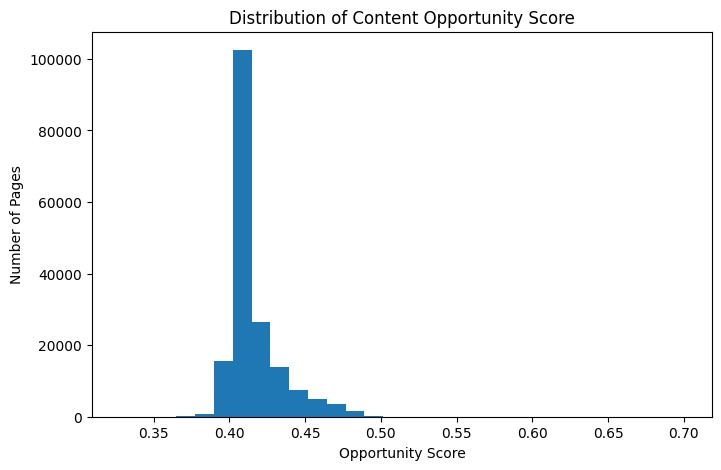

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(content_df["opportunity_score"], bins=30)

plt.title("Distribution of Content Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Pages")

plt.show()

#CTR Distribution

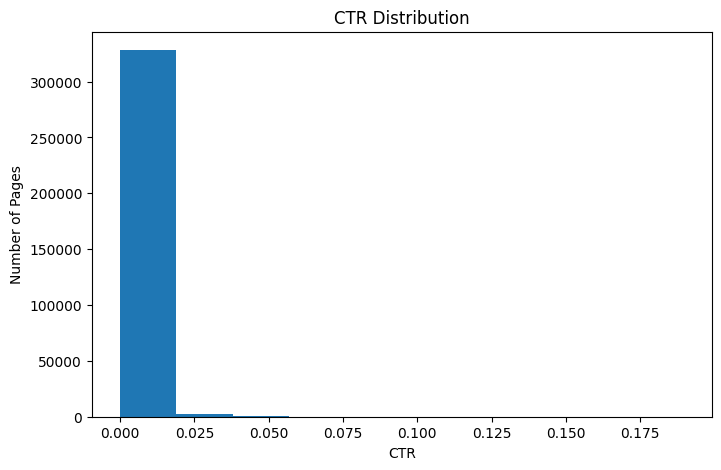

In [19]:
plt.figure(figsize=(8,5))

plt.hist(content_df["ctr"], bins=10)

plt.title("CTR Distribution")
plt.xlabel("CTR")
plt.ylabel("Number of Pages")

plt.show()

#Impressions vs CTR

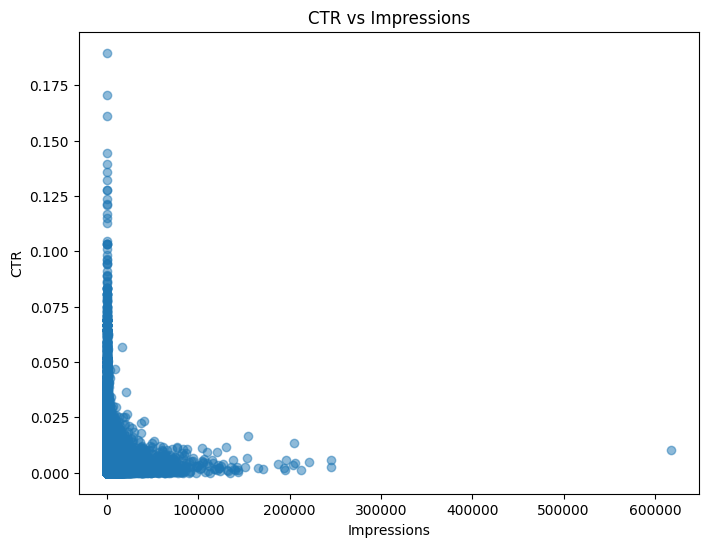

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    content_df["gsc_impressions"],
    content_df["ctr"],
    alpha=0.5
)

plt.title("CTR vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("CTR")

plt.show()

#Top 20 Opportunity Pages

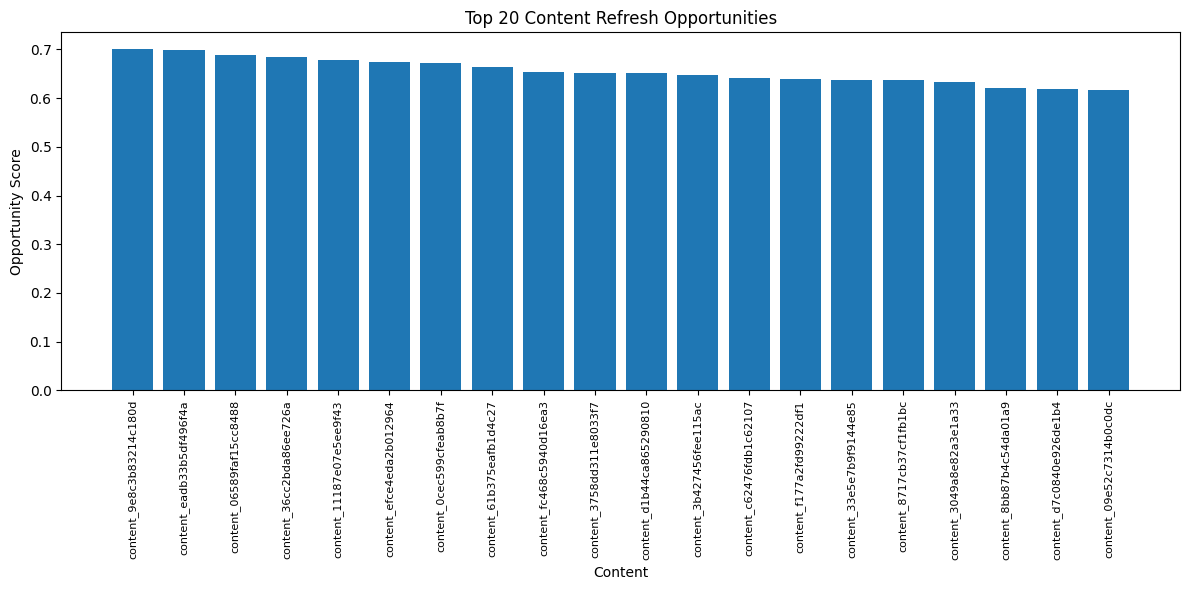

In [21]:
top20 = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top20)),
    top20["opportunity_score"]
)

plt.xticks(
    range(len(top20)),
    top20["content_hash_id"],
    rotation=90,
    fontsize=8
)

plt.title("Top 20 Content Refresh Opportunities")
plt.xlabel("Content")
plt.ylabel("Opportunity Score")

plt.tight_layout()

plt.show()

#Correlation Heatmap

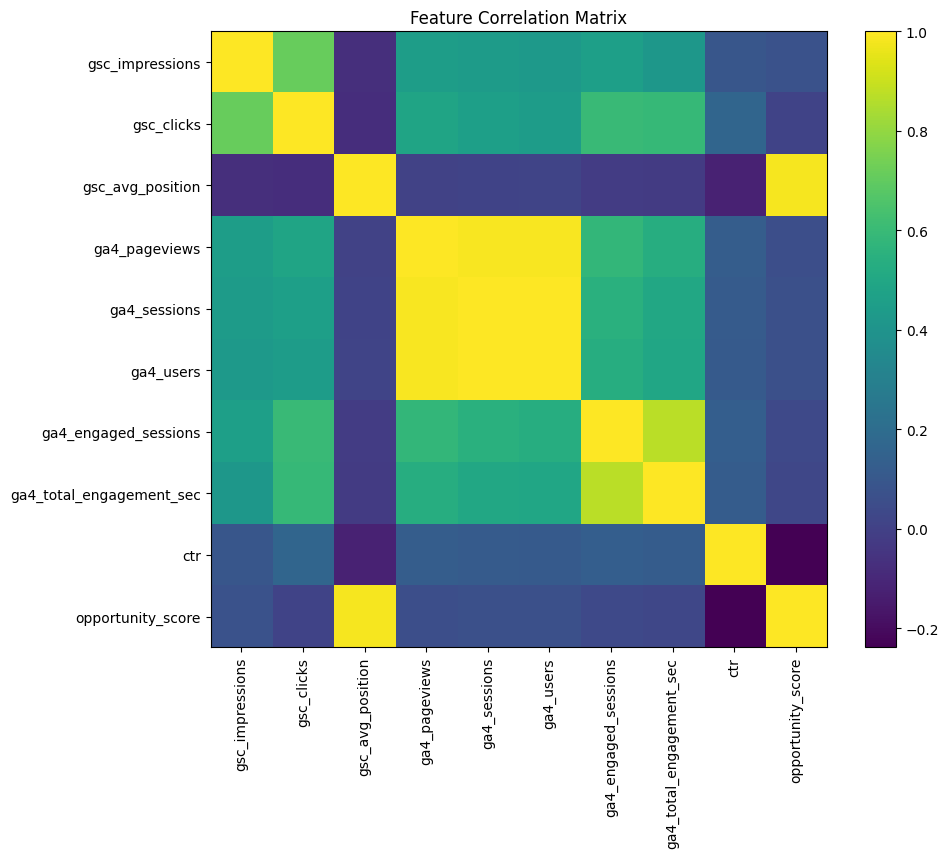

In [22]:
import matplotlib.pyplot as plt

cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "ctr",
    "opportunity_score"
]

corr = content_df[cols].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

#Results Summary

## Summary

The baseline prioritizes content solely based on search impressions. In contrast, the proposed Content Opportunity Score incorporates multiple search performance signals, enabling a more comprehensive ranking of pages that may benefit from review.

Pages with high opportunity scores generally combine high visibility with relatively lower click-through rates or weaker average positions, making them suitable candidates for content refresh.

These findings are intended to support decision-making and should be interpreted as observational rather than causal.

## 5. Limitations

*What this work cannot claim.*

# Limitations

- Results are observational.
- Correlation does not imply causation.
- The model supports decision-making but does not explain Google's ranking algorithm.
- Only available warehouse data was analyzed.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked Recommendations

Based on the Content Opportunity Score, the following actions are recommended.

1. Prioritize pages with high impressions but low CTR for title and meta description improvements.
2. Review pages with declining average search position to identify content gaps.
3. Refresh pages with strong visibility but low engagement.
4. Continue monitoring high-performing pages to maintain performance.
5. Re-evaluate pages with consistently low visibility before investing additional resources.

These recommendations are intended to support content strategy and should be validated by domain experts before implementation.

In [23]:
recommendations = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .copy()
)

recommendations["Recommended Action"] = "Refresh Content"

recommendations[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "opportunity_score",
        "Recommended Action"
    ]
]

,content_hash_id,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,opportunity_score,Recommended Action
205205,content_9e8c3b83214c180d,1,0,0.000000,309.000000,0.700000,Refresh Content
304000,content_eadb33b5df496f4a,617124,5668,0.010076,2.383011,0.698283,Refresh Content
8166,content_06589faf15cc8488,1,0,0.000000,297.000000,0.688350,Refresh Content
70522,content_36cc2bda86ee726a,1,0,0.000000,292.000000,0.683496,Refresh Content
22138,content_11187e07e5ee9f43,1,0,0.000000,286.000000,0.677670,Refresh Content
310341,content_efce4eda2b012964,1,0,0.000000,283.000000,0.674758,Refresh Content
16691,content_0cec599cfeab8b7f,1,0,0.000000,280.000000,0.671845,Refresh Content
126138,content_61b375eafb1d4c27,1,0,0.000000,271.000000,0.663107,Refresh Content
326564,content_fc468c5940d16ea3,1,0,0.000000,262.000000,0.654369,Refresh Content
71280,content_3758dd311e8033f7,1,0,0.000000,260.000000,0.652428,Refresh Content


#Top 20 Recommendations

In [24]:
recommendations = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .copy()
)

recommendations["Recommended Action"] = "Refresh Content"

recommendations[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "opportunity_score",
        "Recommended Action"
    ]
]

,content_hash_id,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,opportunity_score,Recommended Action
205205,content_9e8c3b83214c180d,1,0,0.000000,309.000000,0.700000,Refresh Content
304000,content_eadb33b5df496f4a,617124,5668,0.010076,2.383011,0.698283,Refresh Content
8166,content_06589faf15cc8488,1,0,0.000000,297.000000,0.688350,Refresh Content
70522,content_36cc2bda86ee726a,1,0,0.000000,292.000000,0.683496,Refresh Content
22138,content_11187e07e5ee9f43,1,0,0.000000,286.000000,0.677670,Refresh Content
310341,content_efce4eda2b012964,1,0,0.000000,283.000000,0.674758,Refresh Content
16691,content_0cec599cfeab8b7f,1,0,0.000000,280.000000,0.671845,Refresh Content
126138,content_61b375eafb1d4c27,1,0,0.000000,271.000000,0.663107,Refresh Content
326564,content_fc468c5940d16ea3,1,0,0.000000,262.000000,0.654369,Refresh Content
71280,content_3758dd311e8033f7,1,0,0.000000,260.000000,0.652428,Refresh Content


In [25]:
recommendations.to_csv(
    "top20_content_recommendations.csv",
    index=False
)

print("Top 20 recommendations saved successfully.")

Top 20 recommendations saved successfully.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# Charts and Tables

- Dataset overview
- Missing values
- Feature distributions
- Correlation heatmap
- Feature importance
- Model comparison table
- Top 20 content opportunities

#Save Figures

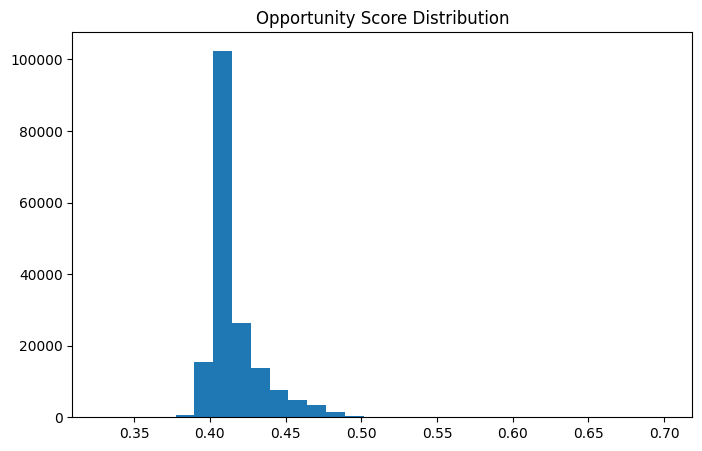

In [26]:
plt.figure(figsize=(8,5))

plt.hist(content_df["opportunity_score"], bins=30)

plt.title("Opportunity Score Distribution")

plt.savefig(
    "opportunity_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

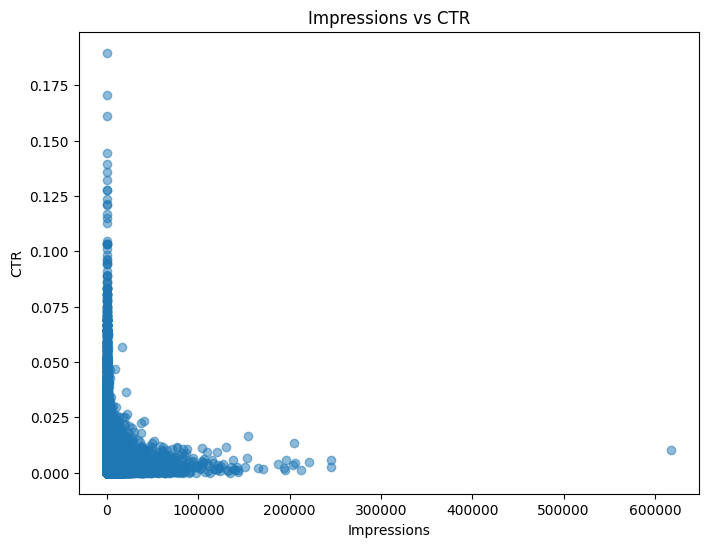

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    content_df["gsc_impressions"],
    content_df["ctr"],
    alpha=0.5
)

plt.xlabel("Impressions")
plt.ylabel("CTR")
plt.title("Impressions vs CTR")

plt.savefig(
    "impressions_vs_ctr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

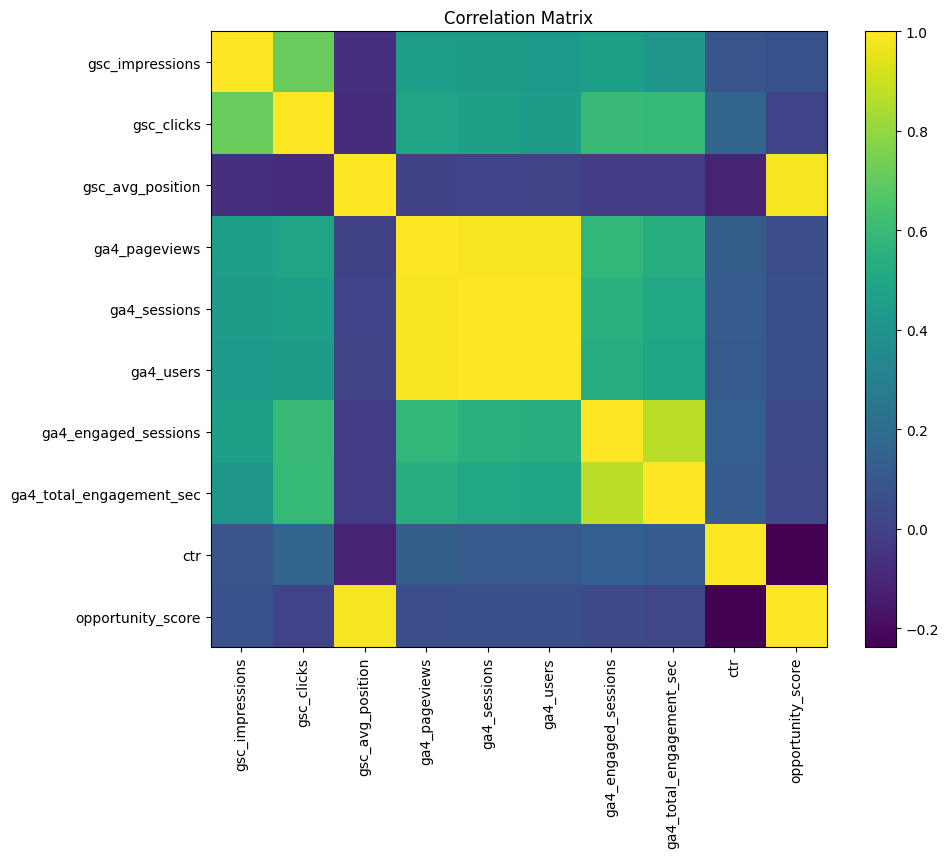

In [28]:
plt.figure(figsize=(10,8))

corr = content_df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",
        "ctr",
        "opportunity_score"
    ]
].corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
content_df["gsc_avg_position"] = content_df["gsc_avg_position"].fillna(
    content_df["gsc_avg_position"].median()
)

In [30]:
print(df["report_date"].min())
print(df["report_date"].max())

print(
    df["report_date"]
    .sort_values()
    .unique()
)

2026-03-01 00:00:00
2026-03-31 00:00:00
<DatetimeArray>
['2026-03-01 00:00:00', '2026-03-02 00:00:00', '2026-03-03 00:00:00',
 '2026-03-04 00:00:00', '2026-03-05 00:00:00', '2026-03-06 00:00:00',
 '2026-03-07 00:00:00', '2026-03-08 00:00:00', '2026-03-09 00:00:00',
 '2026-03-10 00:00:00', '2026-03-11 00:00:00', '2026-03-12 00:00:00',
 '2026-03-13 00:00:00', '2026-03-14 00:00:00', '2026-03-15 00:00:00',
 '2026-03-16 00:00:00', '2026-03-17 00:00:00', '2026-03-18 00:00:00',
 '2026-03-19 00:00:00', '2026-03-20 00:00:00', '2026-03-21 00:00:00',
 '2026-03-22 00:00:00', '2026-03-23 00:00:00', '2026-03-24 00:00:00',
 '2026-03-25 00:00:00', '2026-03-26 00:00:00', '2026-03-27 00:00:00',
 '2026-03-28 00:00:00', '2026-03-29 00:00:00', '2026-03-30 00:00:00',
 '2026-03-31 00:00:00']
Length: 31, dtype: datetime64[us]


In [31]:
df["report_date"] = pd.to_datetime(df["report_date"])

df = df.sort_values("report_date")

print(df["report_date"].min())
print(df["report_date"].max())

2026-03-01 00:00:00
2026-03-31 00:00:00


In [32]:
cutoff_date = pd.Timestamp("2026-03-21")

past_df = df[df["report_date"] <= cutoff_date].copy()
future_df = df[df["report_date"] > cutoff_date].copy()

print("Past data:", past_df.shape)
print("Future data:", future_df.shape)

print("Past:", past_df["report_date"].min(), "to", past_df["report_date"].max())
print("Future:", future_df["report_date"].min(), "to", future_df["report_date"].max())

Past data: (6573997, 11)
Future data: (3267381, 11)
Past: 2026-03-01 00:00:00 to 2026-03-21 00:00:00
Future: 2026-03-22 00:00:00 to 2026-03-31 00:00:00


In [33]:
past_features = (
    past_df.groupby("content_hash_id")
    .agg(
        past_impressions=("gsc_impressions", "sum"),
        past_clicks=("gsc_clicks", "sum"),
        past_avg_position=("gsc_avg_position", "mean"),
        past_pageviews=("ga4_pageviews", "sum"),
        past_sessions=("ga4_sessions", "sum"),
        past_users=("ga4_users", "sum"),
        past_engaged_sessions=("ga4_engaged_sessions", "sum"),
        past_engagement_sec=("ga4_total_engagement_sec", "sum")
    )
    .reset_index()
)

In [34]:
past_features["past_ctr"] = np.where(
    past_features["past_impressions"] > 0,
    past_features["past_clicks"] / past_features["past_impressions"],
    0
)

In [35]:
past_features.head()

,content_hash_id,past_impressions,past_clicks,past_avg_position,past_pageviews,past_sessions,past_users,past_engaged_sessions,past_engagement_sec,past_ctr
0,content_000005d4ced12088,37,0,50.103968,0,0,0,0,0,0.0
1,content_00001e488b74b799,0,0,7.500000,0,0,0,0,0,0.0
2,content_00007bd2985b77c3,30,0,7.176190,0,0,0,0,0,0.0
3,content_00008950670cb6b5,0,0,7.500000,1,1,1,0,0,0.0
4,content_0000a348850eb1fc,0,0,7.500000,1,1,1,0,7,0.0


In [36]:
future_target = (
    future_df.groupby("content_hash_id")
    .agg(
        future_impressions=("gsc_impressions", "sum"),
        future_clicks=("gsc_clicks", "sum"),
        future_avg_position=("gsc_avg_position", "mean"),
        future_pageviews=("ga4_pageviews", "sum"),
        future_sessions=("ga4_sessions", "sum"),
        future_engaged_sessions=("ga4_engaged_sessions", "sum")
    )
    .reset_index()
)

#Future Performance Metrics

In [37]:
future_target["future_ctr"] = np.where(
    future_target["future_impressions"] > 0,
    future_target["future_clicks"] /
    future_target["future_impressions"],
    0
)

#Create Modeling Dataset

In [38]:
model_df = past_features.merge(
    future_target,
    on="content_hash_id",
    how="inner"
)

print(model_df.shape)
model_df.head()

(324296, 17)


,content_hash_id,past_impressions,past_clicks,past_avg_position,past_pageviews,past_sessions,past_users,past_engaged_sessions,past_engagement_sec,past_ctr,future_impressions,future_clicks,future_avg_position,future_pageviews,future_sessions,future_engaged_sessions,future_ctr
0,content_000005d4ced12088,37,0,50.103968,0,0,0,0,0,0.0,49,0,74.883333,0,0,0,0.0
1,content_00001e488b74b799,0,0,7.500000,0,0,0,0,0,0.0,0,0,7.500000,0,0,0,0.0
2,content_00007bd2985b77c3,30,0,7.176190,0,0,0,0,0,0.0,17,0,3.050000,0,0,0,0.0
3,content_00008950670cb6b5,0,0,7.500000,1,1,1,0,0,0.0,0,0,7.500000,1,1,1,0.0
4,content_0000a348850eb1fc,0,0,7.500000,1,1,1,0,7,0.0,0,0,7.500000,0,0,0,0.0


# Define Future Opportunity Threshold

In [39]:
threshold = 1.0

print("Opportunity threshold:", threshold)

Opportunity threshold: 1.0


#Create Opportunity Label

In [40]:
model_df["opportunity_label"] = (
    model_df["future_clicks"] >= threshold
).astype(int)

print(
    model_df["opportunity_label"].value_counts()
)

print(model_df["future_clicks"].describe())

opportunity_label
0    279111
1     45185
Name: count, dtype: int64
count    324296.000000
mean          0.858589
std           7.512402
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2270.000000
Name: future_clicks, dtype: float64


#Define Model Features and Target

In [41]:
X = model_df[
    [
        "past_impressions",
        "past_clicks",
        "past_avg_position",
        "past_pageviews",
        "past_sessions",
        "past_users",
        "past_engaged_sessions",
        "past_engagement_sec",
        "past_ctr"
    ]
]

y = model_df["opportunity_label"]

print("X:", X.shape)
print("y:", y.shape)

X: (324296, 9)
y: (324296,)


#Inspect Opportunity Distribution

In [42]:
print(model_df.shape)
print(y.describe())

print(model_df["future_clicks"].describe())

print(
    model_df["future_clicks"]
    .value_counts()
    .sort_index()
    .head(20)
)

(324296, 18)
count    324296.000000
mean          0.139333
std           0.346294
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: opportunity_label, dtype: float64
count    324296.000000
mean          0.858589
std           7.512402
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2270.000000
Name: future_clicks, dtype: float64
future_clicks
0     279111
1      17173
2       7276
3       4317
4       2818
5       2002
6       1552
7       1277
8        975
9        769
10       686
11       532
12       473
13       401
14      1202
15       300
16       242
17       246
18       225
19       180
Name: count, dtype: int64


#Inspect Future Click Distribution

In [43]:
print(
    model_df["future_clicks"]
    .value_counts()
    .sort_index()
    .head(20)
)

future_clicks
0     279111
1      17173
2       7276
3       4317
4       2818
5       2002
6       1552
7       1277
8        975
9        769
10       686
11       532
12       473
13       401
14      1202
15       300
16       242
17       246
18       225
19       180
Name: count, dtype: int64


#Prepare Model Features and Target

In [44]:
features = [
    "past_impressions",
    "past_clicks",
    "past_avg_position",
    "past_pageviews",
    "past_sessions",
    "past_users",
    "past_engaged_sessions",
    "past_engagement_sec",
    "past_ctr"
]

X = model_df[features].copy()
y = model_df["opportunity_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (324296, 9)
y shape: (324296,)

Class distribution:
opportunity_label
0    279111
1     45185
Name: count, dtype: int64


#Train Majority-Class Baseline

In [45]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X, y)

baseline_pred = baseline.predict(X)

print("Baseline positive predictions:",
      baseline_pred.sum())

Baseline positive predictions: 0


#Create Validation Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (259436, 9)
Validation: (64860, 9)


# Train Random Forest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

model_pred = rf.predict(X_val)
model_prob = rf.predict_proba(X_val)[:, 1]

#Train Majority-Class Baseline

In [48]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(name, y_true, pred, prob):

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall   :", recall_score(y_true, pred, zero_division=0))
    print("F1       :", f1_score(y_true, pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, prob))
    print("PR-AUC   :", average_precision_score(y_true, prob))


evaluate_model(
    "Baseline",
    y_val,
    baseline_pred,
    baseline_prob
)

evaluate_model(
    "Random Forest",
    y_val,
    model_pred,
    model_prob
)


Baseline
----------------------------------------
Accuracy : 0.8606691335183472
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.1393308664816528

Random Forest
----------------------------------------
Accuracy : 0.9199352451433858
Precision: 0.7509138381201045
Recall   : 0.6364944118623437
F1       : 0.6889860453973767
ROC-AUC  : 0.9014368844097694
PR-AUC   : 0.7658919439637246


#Random Forest Confusion Matrix

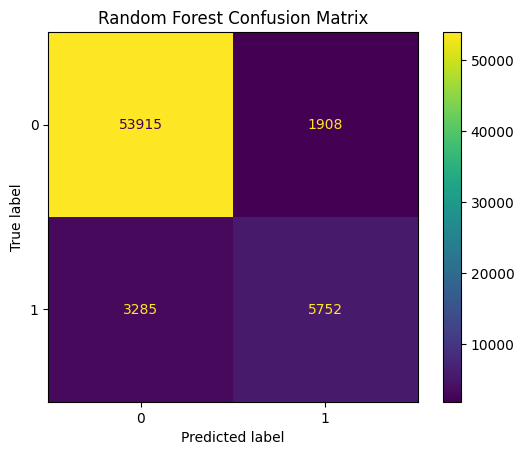

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    model_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Generate Opportunity Probabilities

In [51]:
# Predict probability of future opportunity on validation data
val_results = model_df.loc[X_val.index].copy()

val_results["opportunity_probability"] = rf.predict_proba(X_val)[:, 1]

val_results[
    [
        "content_hash_id",
        "opportunity_probability",
        "past_impressions",
        "past_clicks",
        "past_ctr"
    ]
].head()

,content_hash_id,opportunity_probability,past_impressions,past_clicks,past_ctr
29104,content_1713956bc73e795a,0.048098,0,0,0.000000
240666,content_be39ba7a5fd6a267,0.048098,0,0,0.000000
241757,content_bf128d003449e544,0.310000,496,1,0.002016
283090,content_df9fb6750cfddea7,0.048098,0,0,0.000000
265957,content_d229e4cf6ccd04b8,0.048098,0,0,0.000000


#Rank Top 20 Content Opportunities

In [52]:
top20_recommendations = (
    val_results
    .sort_values(
        "opportunity_probability",
        ascending=False
    )
    .head(20)
    .copy()
)

top20_recommendations[
    [
        "content_hash_id",
        "opportunity_probability",
        "past_impressions",
        "past_clicks",
        "past_ctr",
        "past_avg_position"
    ]
]

,content_hash_id,opportunity_probability,past_impressions,past_clicks,past_ctr,past_avg_position
312962,content_f72012f480caf77f,1.0,1912,8,0.004184,9.841383
156407,content_7bb2ebb373ff8987,1.0,27887,44,0.001578,5.384616
305562,content_f14d4997cd8ef5c9,1.0,6756,26,0.003848,3.649305
180510,content_8eba2d99238592aa,1.0,28266,138,0.004882,3.747180
63376,content_324c01e2a559ad73,1.0,5182,39,0.007526,3.095681
49163,content_271a45e959bfc1fc,1.0,22259,83,0.003729,3.884184
65926,content_346802e533db7b8e,1.0,6759,39,0.005770,3.778977
261861,content_cef23821be36fbf5,1.0,2775,19,0.006847,3.593970
60863,content_304c1b1491813d9b,1.0,8100,17,0.002099,3.680172
25847,content_14754ac78932ab6a,1.0,8098,30,0.003705,18.488020


#Generate Recommendation Reason Codes

In [53]:
# Calculate historical medians once
impressions_median = model_df["past_impressions"].median()
ctr_median = model_df["past_ctr"].median()
position_median = model_df["past_avg_position"].median()


def get_reason(row):

    reasons = []

    if row["past_impressions"] > impressions_median:
        reasons.append("high visibility")

    if row["past_ctr"] < ctr_median:
        reasons.append("low CTR")

    if row["past_avg_position"] > position_median:
        reasons.append("weaker average position")

    if row["past_clicks"] == 0:
        reasons.append("no historical clicks")

    if not reasons:
        reasons.append("model-ranked opportunity")

    return ", ".join(reasons)


top20_recommendations["reason"] = (
    top20_recommendations.apply(
        get_reason,
        axis=1
    )
)

#Create Final Ranked Recommendations

In [54]:
final_recommendations = top20_recommendations[
    [
        "content_hash_id",
        "opportunity_probability",
        "past_impressions",
        "past_clicks",
        "past_ctr",
        "past_avg_position",
        "reason"
    ]
].copy()

final_recommendations.index = range(1, len(final_recommendations) + 1)

display(final_recommendations)

,content_hash_id,opportunity_probability,past_impressions,past_clicks,past_ctr,past_avg_position,reason
1,content_f72012f480caf77f,1.0,1912,8,0.004184,9.841383,"high visibility, weaker average position"
2,content_7bb2ebb373ff8987,1.0,27887,44,0.001578,5.384616,high visibility
3,content_f14d4997cd8ef5c9,1.0,6756,26,0.003848,3.649305,high visibility
4,content_8eba2d99238592aa,1.0,28266,138,0.004882,3.747180,high visibility
5,content_324c01e2a559ad73,1.0,5182,39,0.007526,3.095681,high visibility
6,content_271a45e959bfc1fc,1.0,22259,83,0.003729,3.884184,high visibility
7,content_346802e533db7b8e,1.0,6759,39,0.005770,3.778977,high visibility
8,content_cef23821be36fbf5,1.0,2775,19,0.006847,3.593970,high visibility
9,content_304c1b1491813d9b,1.0,8100,17,0.002099,3.680172,high visibility
10,content_14754ac78932ab6a,1.0,8098,30,0.003705,18.488020,"high visibility, weaker average position"


#Export Ranked Recommendations

In [55]:
final_recommendations.to_csv(
    "ranked_content_recommendations.csv"
    )

print("Recommendations saved successfully.")

Recommendations saved successfully.


#Visualize Top 20 Ranked Opportunities

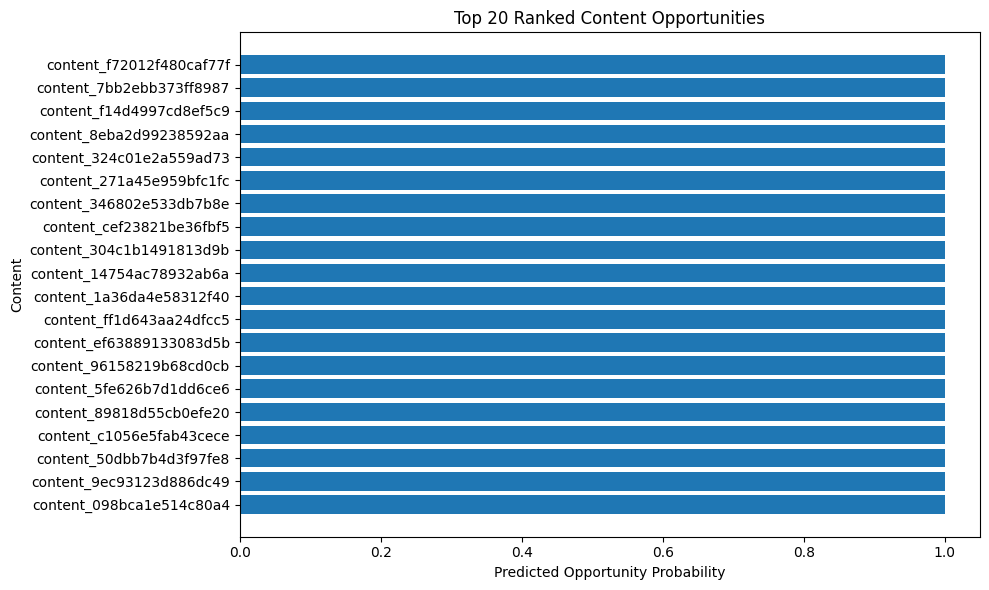

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    final_recommendations["content_hash_id"].astype(str),
    final_recommendations["opportunity_probability"]
)

plt.xlabel("Predicted Opportunity Probability")
plt.ylabel("Content")
plt.title("Top 20 Ranked Content Opportunities")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Ranked Recommendations

The model was used to rank content by predicted probability of receiving future clicks.

The highest-ranked content represents pages that the model identifies as stronger candidates for review based on historical search and engagement signals.

Reason codes provide an interpretable explanation for each recommendation, such as high visibility, low CTR, or weaker average search position.

These rankings are directional and intended to support content-review prioritization. They do not imply that refreshing a page will cause future performance to improve.

# Validate Top 20 Recommendations

In [57]:
top20_evidence = top20_recommendations[
    [
        "content_hash_id",
        "opportunity_probability",
        "past_impressions",
        "past_clicks",
        "past_ctr",
        "past_avg_position"
    ]
].merge(
    val_results[
        [
            "content_hash_id",
            "future_clicks",
            "future_impressions",
            "future_ctr"
        ]
    ],
    on="content_hash_id",
    how="left"
)

display(top20_evidence)

,content_hash_id,opportunity_probability,past_impressions,past_clicks,past_ctr,past_avg_position,future_clicks,future_impressions,future_ctr
0,content_f72012f480caf77f,1.0,1912,8,0.004184,9.841383,14,3079,0.004547
1,content_7bb2ebb373ff8987,1.0,27887,44,0.001578,5.384616,26,14941,0.001740
2,content_f14d4997cd8ef5c9,1.0,6756,26,0.003848,3.649305,8,4700,0.001702
3,content_8eba2d99238592aa,1.0,28266,138,0.004882,3.747180,73,17233,0.004236
4,content_324c01e2a559ad73,1.0,5182,39,0.007526,3.095681,11,3285,0.003349
5,content_271a45e959bfc1fc,1.0,22259,83,0.003729,3.884184,38,15307,0.002483
6,content_346802e533db7b8e,1.0,6759,39,0.005770,3.778977,43,13733,0.003131
7,content_cef23821be36fbf5,1.0,2775,19,0.006847,3.593970,2,1311,0.001526
8,content_304c1b1491813d9b,1.0,8100,17,0.002099,3.680172,6,2074,0.002893
9,content_14754ac78932ab6a,1.0,8098,30,0.003705,18.488020,19,4420,0.004299


#Validate Top 20 Opportunity Rate

In [58]:
top20_evidence["actual_opportunity"] = (
    top20_evidence["future_clicks"] >= threshold
).astype(int)

print(
    "Actual opportunities in Top 20:",
    top20_evidence["actual_opportunity"].sum(),
    "out of",
    len(top20_evidence)
)

Actual opportunities in Top 20: 20 out of 20


#Calculate Precision@20

In [59]:
precision_at_20 = (
    top20_evidence["actual_opportunity"].sum()
    / len(top20_evidence)
)

print(f"Precision@20: {precision_at_20:.3f}")

Precision@20: 1.000


#Compare Against Random Selection

In [60]:
random_sample = val_results.sample(
    n=20,
    random_state=42
).copy()

random_sample["actual_opportunity"] = (
    random_sample["future_clicks"] >= threshold
).astype(int)

random_precision_at_20 = (
    random_sample["actual_opportunity"].sum()
    / len(random_sample)
)

print(
    f"Random Precision@20: {random_precision_at_20:.3f}"
)

Random Precision@20: 0.100


#Compare Ranking Strategies

In [61]:
ranking_comparison = pd.DataFrame({
    "Strategy": [
        "Random selection",
        "Random Forest ranking"
    ],
    "Precision@20": [
        random_precision_at_20,
        precision_at_20
    ]
})

display(ranking_comparison)

,Strategy,Precision@20
0,Random selection,0.1
1,Random Forest ranking,1.0


#Create Final Paper Results Table

In [62]:
final_paper_table = top20_evidence[
    [
        "content_hash_id",
        "opportunity_probability",
        "past_impressions",
        "past_clicks",
        "past_ctr",
        "past_avg_position",
        "future_clicks",
        "future_ctr",
        "actual_opportunity"
    ]
].copy()

final_paper_table.index = range(
    1,
    len(final_paper_table) + 1
)

display(final_paper_table)

,content_hash_id,opportunity_probability,past_impressions,past_clicks,past_ctr,past_avg_position,future_clicks,future_ctr,actual_opportunity
1,content_f72012f480caf77f,1.0,1912,8,0.004184,9.841383,14,0.004547,1
2,content_7bb2ebb373ff8987,1.0,27887,44,0.001578,5.384616,26,0.001740,1
3,content_f14d4997cd8ef5c9,1.0,6756,26,0.003848,3.649305,8,0.001702,1
4,content_8eba2d99238592aa,1.0,28266,138,0.004882,3.747180,73,0.004236,1
5,content_324c01e2a559ad73,1.0,5182,39,0.007526,3.095681,11,0.003349,1
6,content_271a45e959bfc1fc,1.0,22259,83,0.003729,3.884184,38,0.002483,1
7,content_346802e533db7b8e,1.0,6759,39,0.005770,3.778977,43,0.003131,1
8,content_cef23821be36fbf5,1.0,2775,19,0.006847,3.593970,2,0.001526,1
9,content_304c1b1491813d9b,1.0,8100,17,0.002099,3.680172,6,0.002893,1
10,content_14754ac78932ab6a,1.0,8098,30,0.003705,18.488020,19,0.004299,1


#Rank Validation Opportunities by Predicted Probability

In [63]:
# Validation set probabilities
val_results = model_df.loc[X_val.index].copy()

val_results["opportunity_probability"] = (
    rf.predict_proba(X_val)[:, 1]
)

val_results = val_results.sort_values(
    "opportunity_probability",
    ascending=False
)

display(
    val_results[
        [
            "content_hash_id",
            "opportunity_probability",
            "opportunity_label",
            "future_clicks"
        ]
    ].head(20)
)

,content_hash_id,opportunity_probability,opportunity_label,future_clicks
312962,content_f72012f480caf77f,1.0,1,14
156407,content_7bb2ebb373ff8987,1.0,1,26
305562,content_f14d4997cd8ef5c9,1.0,1,8
180510,content_8eba2d99238592aa,1.0,1,73
63376,content_324c01e2a559ad73,1.0,1,11
49163,content_271a45e959bfc1fc,1.0,1,38
65926,content_346802e533db7b8e,1.0,1,43
261861,content_cef23821be36fbf5,1.0,1,2
60863,content_304c1b1491813d9b,1.0,1,6
25847,content_14754ac78932ab6a,1.0,1,19


#Calculate Validation Precision@20

In [64]:
top20_val = val_results.head(20).copy()

precision_at_20_val = (
    top20_val["opportunity_label"].sum()
    / len(top20_val)
)

print(f"Validation Precision@20: {precision_at_20_val:.3f}")
print(
    "Actual opportunities:",
    top20_val["opportunity_label"].sum(),
    "out of",
    len(top20_val)
)

Validation Precision@20: 1.000
Actual opportunities: 20 out of 20


#Compare Against Random Validation Selection

In [65]:
random_val = model_df.loc[X_val.index].sample(
    n=20,
    random_state=42
).copy()

random_precision_at_20 = (
    random_val["opportunity_label"].sum()
    / len(random_val)
)

print(f"Random Precision@20: {random_precision_at_20:.3f}")

Random Precision@20: 0.100


#Compare Ranking Strategies

In [66]:
ranking_results = pd.DataFrame({
    "Strategy": [
        "Random selection",
        "Random Forest ranking"
    ],
    "Precision@20": [
        random_precision_at_20,
        precision_at_20_val
    ]
})

display(ranking_results)

,Strategy,Precision@20
0,Random selection,0.1
1,Random Forest ranking,1.0


#Compare Model Performance with Baseline

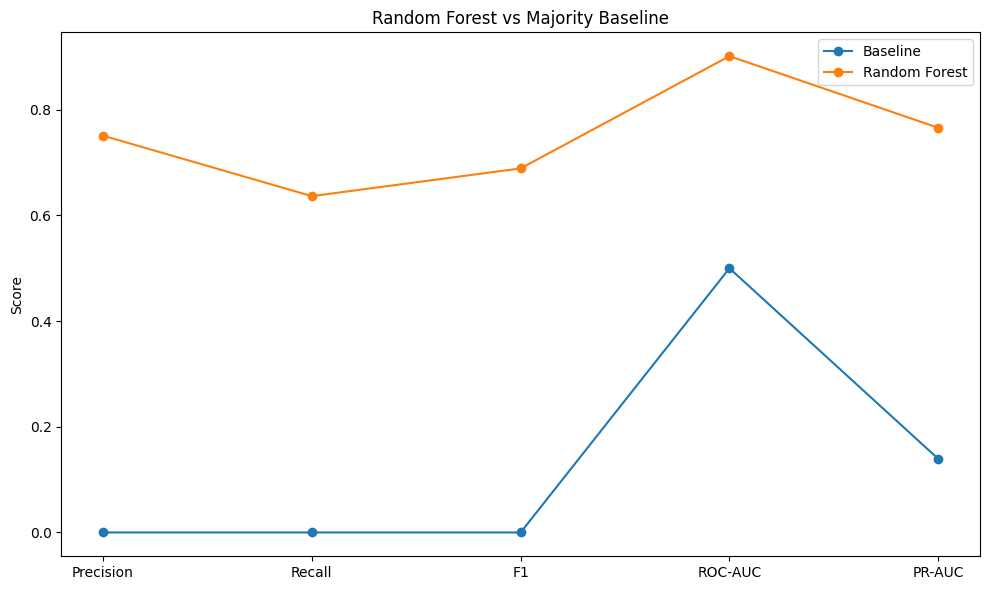

In [67]:
import matplotlib.pyplot as plt

metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

baseline_scores = [
    precision_score(y_val, baseline_pred, zero_division=0),
    recall_score(y_val, baseline_pred, zero_division=0),
    f1_score(y_val, baseline_pred, zero_division=0),
    roc_auc_score(y_val, baseline_prob),
    average_precision_score(y_val, baseline_prob)
]

rf_scores = [
    precision_score(y_val, model_pred, zero_division=0),
    recall_score(y_val, model_pred, zero_division=0),
    f1_score(y_val, model_pred, zero_division=0),
    roc_auc_score(y_val, model_prob),
    average_precision_score(y_val, model_prob)
]

x = range(len(metrics))

plt.figure(figsize=(10, 6))

plt.plot(x, baseline_scores, marker="o", label="Baseline")
plt.plot(x, rf_scores, marker="o", label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest vs Majority Baseline")
plt.legend()

plt.tight_layout()
plt.show()

# Feature Importance

The Random Forest feature importances are used to summarize which historical features contributed most to the model's predictions. These are model-derived associations and should not be interpreted as causal effects.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
0,past_impressions,0.374023
2,past_avg_position,0.200763
8,past_ctr,0.189031
1,past_clicks,0.177454
3,past_pageviews,0.020577
4,past_sessions,0.015065
7,past_engagement_sec,0.010970
5,past_users,0.010829
6,past_engaged_sessions,0.001289


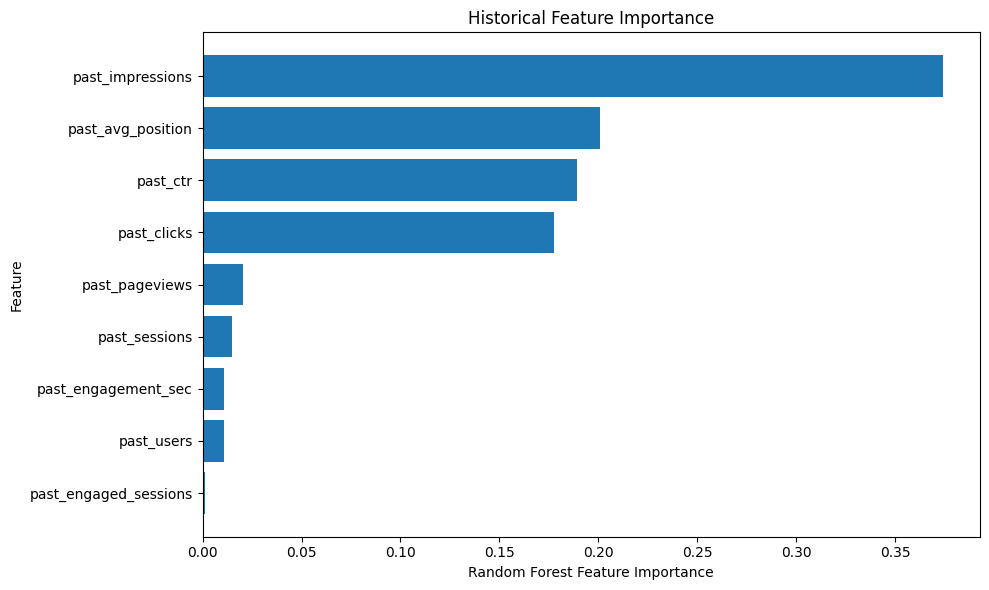

In [69]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Historical Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Limitations and Honest Framing

This analysis is based on observed FlyRank search and engagement data from the March 2026 analysis window.

The model identifies directional patterns associated with future opportunity; it does not establish causation or prove that changing a content item will produce a specific search outcome.

The validation period is limited to the available future window, so performance may differ on other periods or datasets.

Precision@20 is based on one held-out validation set and should not be treated as a universal performance guarantee.

The random comparison uses one fixed-seed sample and is provided as a simple reference rather than a definitive estimate of random-selection performance.

Recommendations are intended for decision support and content review prioritization, not automated publishing decisions.

# Artifacts and Reproducibility

The notebook produces the following artifacts for the research paper:

- Model-versus-baseline performance chart
- Random Forest confusion matrix
- Historical feature importance chart
- Top-20 ranked opportunity table
- Precision@20 comparison
- Ranked content recommendations CSV

The analysis uses the same held-out validation split for baseline and Random Forest evaluation.

The recommendation ranking is based on predicted opportunity probability, while future-period outcomes are used only for validation and evaluation.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.